Below is a practical starter solution for a buy-and-build cross-sell + margin leak use case, implemented as a Google ADK agent scaffold in Python. I’m tailoring it to a concrete demo rather than a generic framework sketch.

The public ADK docs describe Agent Development Kit (ADK) as an open-source framework for building, debugging and deploying AI agents, with support for agents, workflows, tools and local development via CLI or web UI. This solution emphasises human-in-the-loop, tool-driven agents, and decomposing workflows into smaller specialist steps rather than relying on a giant monolithic prompt. Thus it provides: one ADK root agent, a set of deterministic Python tools, and an approval gate before any commercial recommendation is acted on.

This ADK solution will:

1. Resolve a customer across acquired subsidiaries
2. Find cross-sell opportunities across the group
3. Detect margin leaks in jobs / contracts
4. Prioritise recommended actions
5. Require human approval for medium-confidence or pricing-sensitive actions

Here's a sample Certek Pharma use case, the subsidiaries are:
- AlphaBiolabs for workplace / health / toxicology-style testing.
- JSS Medical Research for CRO / clinical / post-approval support.
- ARC Pharma for QC batch release and analytical testing.

There are 2 agents:
1. Insights Agent that helps derive insights from shared data
2. Synergy Agent that helps identify synergies between subsidiaries

In [ ]:
model_name="gemini-3.1-flash-lite"
api_key="<give key here>"
import os
import pandas as pd
from datetime import datetime, timedelta
from typing import Optional
from google import genai

### Gemini Invocation

In [3]:
def call_gemini_direct(prompt: str) -> str:
    """
    Calls Gemini directly with an API key passed in code.
    This bypasses ADK's native Gemini auth path.
    """
    client = genai.Client(api_key=api_key)

    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
    )

    return response.text

In [4]:

from functools import cached_property
from google.genai import Client, types
from google.adk.models.google_llm import Gemini

class GeminiWithApiKey(Gemini):
    api_key: str

    @cached_property
    def api_client(self) -> Client:
        return Client(
            api_key=self.api_key,
            http_options=types.HttpOptions(headers=self._tracking_headers()),
        )

### Synthetic Data Set Up and Overview

Six DataFrames form the in-memory data layer for this demo. Each maps to a CSV file that would be loaded from `data/` in a production deployment.

---

**`subsidiaries`** — the three acquired group entities (3 rows × 4 cols)
- `subsidiary_id`: unique identifier — S1, S2, S3
- `subsidiary_name`: AlphaBiolabs (workplace/health testing), JSS Medical Research (CRO/clinical), ARC Pharma (QC/analytical)
- `target_margin_pct`: group-level gross margin target for that entity — 46%, 34%, 41%
- `current_capacity_pct`: current utilisation as % of total delivery capacity — used to downweight cross-sell recommendations to over-stretched subsidiaries

---

**`services`** — the service catalogue across all three subsidiaries (7 rows × 5 cols)
- `service_id`: unique identifier — SV1, SV2, SV4–SV8 (no SV3 in this dataset)
- `service_name`: e.g. Workplace Drug Testing, Phase II/III Clinical Operations, QC Batch Release Testing
- `provider_subsidiary_id`: which subsidiary delivers the service (S1, S2 or S3)
- `avg_deal_size_gbp`: average annual contract value — ranges from £18k (Occupational Health) to £250k (Phase II/III)
- `target_margin_pct`: expected gross margin for that service line — used as the benchmark in margin leak detection

---

**`customers`** — known group customer accounts (6 rows × 5 cols)
- `customer_id`: unique identifier — C101 to C106
- `customer_name`: e.g. MedNova Pharma, BioSterile Therapeutics, NorthBridge Manufacturing
- `sector`: industry vertical — Pharma, Biotech, Nutraceutical, Diagnostics, Industrial Employer
- `region`: geographic region — UK, EU, North America, Global
- `current_group_spend_gbp`: total spend across all subsidiaries in the last 12 months — ranges from £95k (NorthBridge) to £510k (Regenera)

---

**`history`** — customer service purchase history over the last 12 months (7 rows × 5 cols)
- `customer_id`: links to `customers`
- `service_id`: which service was purchased — links to `services`
- `provider_subsidiary_id`: which subsidiary fulfilled the engagement
- `total_spend_12m_gbp`: total spend on that service in the period
- `purchase_count_12m`: number of discrete purchases — C105 (NorthBridge) has the highest frequency at 6, indicating a recurring operational relationship

---

**`adjacency`** — cross-sell rules derived from co-purchase patterns (5 rows × 4 cols)
- `anchor_service_id`: the service the customer currently buys
- `recommended_service_id`: the service to recommend next
- `base_confidence`: probability (0–1) that a customer buying the anchor will convert on the recommendation — highest pairing is SV4→SV7 at 0.84
- `reason`: plain-English explanation of the commercial logic behind each pairing

---

**`jobs`** — individual job-level delivery and cost records (3 rows × 12 cols)
- `job_id`: unique job reference — J1001, J1003, J1005
- `customer_id` / `subsidiary_id` / `service_id`: foreign keys linking to their respective tables
- `quoted_value_gbp`: the value agreed at point of sale
- `invoiced_value_gbp`: the value actually billed — any gap from quoted indicates quote-to-invoice erosion
- `direct_labour_gbp`, `travel_logistics_gbp`, `subcontract_gbp`, `rework_gbp`, `other_direct_cost_gbp`: itemised direct cost buckets used to compute actual gross margin
- `rush_flag`: Y/N — J1001 and J1005 are rush jobs, a key contributor to margin compression in both cases

In [5]:
import pandas as pd

# ------------------------------
# Subsidiaries
# ------------------------------
subsidiaries = pd.DataFrame([
    {"subsidiary_id": "S1", "subsidiary_name": "AlphaBiolabs", "target_margin_pct": 46, "current_capacity_pct": 72},
    {"subsidiary_id": "S2", "subsidiary_name": "JSS Medical Research", "target_margin_pct": 34, "current_capacity_pct": 68},
    {"subsidiary_id": "S3", "subsidiary_name": "ARC Pharma", "target_margin_pct": 41, "current_capacity_pct": 63},
])

# ------------------------------
# Service Catalogue
# ------------------------------
services = pd.DataFrame([
    {"service_id": "SV1", "service_name": "Workplace Drug Testing", "provider_subsidiary_id": "S1", "avg_deal_size_gbp": 28000, "target_margin_pct": 48},
    {"service_id": "SV2", "service_name": "Occupational Health Screening", "provider_subsidiary_id": "S1", "avg_deal_size_gbp": 18000, "target_margin_pct": 44},
    {"service_id": "SV4", "service_name": "Phase II/III Clinical Operations", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 250000, "target_margin_pct": 33},
    {"service_id": "SV5", "service_name": "Post-Approval Studies", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 175000, "target_margin_pct": 36},
    {"service_id": "SV6", "service_name": "Medical Writing & Data Management", "provider_subsidiary_id": "S2", "avg_deal_size_gbp": 95000, "target_margin_pct": 38},
    {"service_id": "SV7", "service_name": "QC Batch Release Testing", "provider_subsidiary_id": "S3", "avg_deal_size_gbp": 140000, "target_margin_pct": 42},
    {"service_id": "SV8", "service_name": "Method Validation", "provider_subsidiary_id": "S3", "avg_deal_size_gbp": 85000, "target_margin_pct": 45},
])

# ------------------------------
# Customers
# ------------------------------
customers = pd.DataFrame([
    {"customer_id": "C101", "customer_name": "MedNova Pharma", "sector": "Pharma", "region": "UK", "current_group_spend_gbp": 420000},
    {"customer_id": "C102", "customer_name": "BioSterile Therapeutics", "sector": "Biotech", "region": "EU", "current_group_spend_gbp": 260000},
    {"customer_id": "C103", "customer_name": "NutriHealth Labs", "sector": "Nutraceutical", "region": "North America", "current_group_spend_gbp": 180000},
    {"customer_id": "C104", "customer_name": "CareGene Diagnostics", "sector": "Diagnostics", "region": "UK", "current_group_spend_gbp": 140000},
    {"customer_id": "C105", "customer_name": "NorthBridge Manufacturing", "sector": "Industrial Employer", "region": "UK", "current_group_spend_gbp": 95000},
    {"customer_id": "C106", "customer_name": "Regenera Life Sciences", "sector": "Pharma", "region": "Global", "current_group_spend_gbp": 510000},
])

# ------------------------------
# Customer Service History
# ------------------------------
history = pd.DataFrame([
    {"customer_id": "C101", "service_id": "SV4", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 420000, "purchase_count_12m": 2},
    {"customer_id": "C102", "service_id": "SV7", "provider_subsidiary_id": "S3", "total_spend_12m_gbp": 260000, "purchase_count_12m": 4},
    {"customer_id": "C103", "service_id": "SV5", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 180000, "purchase_count_12m": 1},
    {"customer_id": "C104", "service_id": "SV2", "provider_subsidiary_id": "S1", "total_spend_12m_gbp": 140000, "purchase_count_12m": 5},
    {"customer_id": "C105", "service_id": "SV1", "provider_subsidiary_id": "S1", "total_spend_12m_gbp": 95000, "purchase_count_12m": 6},
    {"customer_id": "C106", "service_id": "SV7", "provider_subsidiary_id": "S3", "total_spend_12m_gbp": 310000, "purchase_count_12m": 3},
    {"customer_id": "C106", "service_id": "SV6", "provider_subsidiary_id": "S2", "total_spend_12m_gbp": 200000, "purchase_count_12m": 2},
])

# ------------------------------
# Cross-sell Adjacency Rules
# ------------------------------
adjacency = pd.DataFrame([
    {"anchor_service_id": "SV4", "recommended_service_id": "SV7", "base_confidence": 0.84, "reason": "Phase II/III clients often need QC batch release"},
    {"anchor_service_id": "SV5", "recommended_service_id": "SV7", "base_confidence": 0.76, "reason": "Post-approval studies pair naturally with batch release"},
    {"anchor_service_id": "SV7", "recommended_service_id": "SV5", "base_confidence": 0.78, "reason": "Batch release clients often need post-approval support"},
    {"anchor_service_id": "SV7", "recommended_service_id": "SV6", "base_confidence": 0.69, "reason": "Batch release clients frequently need medical writing"},
    {"anchor_service_id": "SV1", "recommended_service_id": "SV2", "base_confidence": 0.66, "reason": "Drug testing employers often add occupational health screening"},
])

# ------------------------------
# Jobs (for margin analysis)
# ------------------------------
jobs = pd.DataFrame([
    # C105 NorthBridge | S1 AlphaBiolabs | spend cap £95k
    {"job_id": "J1001", "customer_id": "C105", "subsidiary_id": "S1", "service_id": "SV1", "quoted_value_gbp": 18500, "invoiced_value_gbp": 17800, "direct_labour_gbp": 6200, "travel_logistics_gbp": 1700, "subcontract_gbp": 0, "rework_gbp": 1800, "other_direct_cost_gbp": 1200, "rush_flag": "Y"},
    {"job_id": "J1002", "customer_id": "C105", "subsidiary_id": "S1", "service_id": "SV2", "quoted_value_gbp": 19000, "invoiced_value_gbp": 18500, "direct_labour_gbp": 7200, "travel_logistics_gbp": 900, "subcontract_gbp": 0, "rework_gbp": 400, "other_direct_cost_gbp": 800, "rush_flag": "N"},
    # C101 MedNova Pharma | S2 JSS Medical Research | spend cap £420k
    {"job_id": "J1003", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV4", "quoted_value_gbp": 96000, "invoiced_value_gbp": 96000, "direct_labour_gbp": 51200, "travel_logistics_gbp": 6800, "subcontract_gbp": 4200, "rework_gbp": 3200, "other_direct_cost_gbp": 9000, "rush_flag": "N"},
    {"job_id": "J1004", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV5", "quoted_value_gbp": 85000, "invoiced_value_gbp": 82000, "direct_labour_gbp": 38000, "travel_logistics_gbp": 5200, "subcontract_gbp": 2000, "rework_gbp": 4500, "other_direct_cost_gbp": 7000, "rush_flag": "N"},
    {"job_id": "J1006", "customer_id": "C101", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 48000, "invoiced_value_gbp": 48000, "direct_labour_gbp": 19500, "travel_logistics_gbp": 1200, "subcontract_gbp": 0, "rework_gbp": 800, "other_direct_cost_gbp": 3500, "rush_flag": "N"},
    # C102 BioSterile Therapeutics | S3 ARC Pharma | spend cap £260k
    {"job_id": "J1005", "customer_id": "C102", "subsidiary_id": "S3", "service_id": "SV7", "quoted_value_gbp": 42000, "invoiced_value_gbp": 42000, "direct_labour_gbp": 15900, "travel_logistics_gbp": 900, "subcontract_gbp": 0, "rework_gbp": 5400, "other_direct_cost_gbp": 11400, "rush_flag": "Y"},
    {"job_id": "J1007", "customer_id": "C102", "subsidiary_id": "S3", "service_id": "SV8", "quoted_value_gbp": 55000, "invoiced_value_gbp": 54000, "direct_labour_gbp": 19000, "travel_logistics_gbp": 1100, "subcontract_gbp": 0, "rework_gbp": 2200, "other_direct_cost_gbp": 5800, "rush_flag": "N"},
    # C103 NutriHealth Labs | S2 JSS Medical Research | spend cap £180k
    {"job_id": "J1008", "customer_id": "C103", "subsidiary_id": "S2", "service_id": "SV5", "quoted_value_gbp": 90000, "invoiced_value_gbp": 88000, "direct_labour_gbp": 39000, "travel_logistics_gbp": 3200, "subcontract_gbp": 1500, "rework_gbp": 1200, "other_direct_cost_gbp": 6500, "rush_flag": "N"},
    {"job_id": "J1009", "customer_id": "C103", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 45000, "invoiced_value_gbp": 43000, "direct_labour_gbp": 17500, "travel_logistics_gbp": 1400, "subcontract_gbp": 0, "rework_gbp": 3100, "other_direct_cost_gbp": 4200, "rush_flag": "Y"},
    # C104 CareGene Diagnostics | S1 AlphaBiolabs | spend cap £140k
    {"job_id": "J1010", "customer_id": "C104", "subsidiary_id": "S1", "service_id": "SV2", "quoted_value_gbp": 38000, "invoiced_value_gbp": 38000, "direct_labour_gbp": 15200, "travel_logistics_gbp": 800, "subcontract_gbp": 0, "rework_gbp": 500, "other_direct_cost_gbp": 2800, "rush_flag": "N"},
    {"job_id": "J1011", "customer_id": "C104", "subsidiary_id": "S1", "service_id": "SV1", "quoted_value_gbp": 29000, "invoiced_value_gbp": 27500, "direct_labour_gbp": 10800, "travel_logistics_gbp": 1600, "subcontract_gbp": 0, "rework_gbp": 2900, "other_direct_cost_gbp": 2200, "rush_flag": "Y"},
    # C106 Regenera Life Sciences | S2 JSS Medical Research + S3 ARC Pharma | spend cap £510k
    {"job_id": "J1012", "customer_id": "C106", "subsidiary_id": "S3", "service_id": "SV7", "quoted_value_gbp": 145000, "invoiced_value_gbp": 145000, "direct_labour_gbp": 54000, "travel_logistics_gbp": 3800, "subcontract_gbp": 2500, "rework_gbp": 1800, "other_direct_cost_gbp": 11200, "rush_flag": "N"},
    {"job_id": "J1013", "customer_id": "C106", "subsidiary_id": "S3", "service_id": "SV8", "quoted_value_gbp": 88000, "invoiced_value_gbp": 86000, "direct_labour_gbp": 31000, "travel_logistics_gbp": 2100, "subcontract_gbp": 0, "rework_gbp": 4200, "other_direct_cost_gbp": 7500, "rush_flag": "N"},
    {"job_id": "J1014", "customer_id": "C106", "subsidiary_id": "S2", "service_id": "SV6", "quoted_value_gbp": 97000, "invoiced_value_gbp": 95000, "direct_labour_gbp": 38500, "travel_logistics_gbp": 2600, "subcontract_gbp": 1000, "rework_gbp": 1500, "other_direct_cost_gbp": 8200, "rush_flag": "N"},
])

In [6]:
customers

,customer_id,customer_name,sector,region,current_group_spend_gbp
0,C101,MedNova Pharma,Pharma,UK,420000
1,C102,BioSterile Therapeutics,Biotech,EU,260000
2,C103,NutriHealth Labs,Nutraceutical,North America,180000
3,C104,CareGene Diagnostics,Diagnostics,UK,140000
4,C105,NorthBridge Manufacturing,Industrial Employer,UK,95000
5,C106,Regenera Life Sciences,Pharma,Global,510000


In [7]:
subsidiaries

,subsidiary_id,subsidiary_name,target_margin_pct,current_capacity_pct
0,S1,AlphaBiolabs,46,72
1,S2,JSS Medical Research,34,68
2,S3,ARC Pharma,41,63


In [8]:
services

,service_id,service_name,provider_subsidiary_id,avg_deal_size_gbp,target_margin_pct
0,SV1,Workplace Drug Testing,S1,28000,48
1,SV2,Occupational Health Screening,S1,18000,44
2,SV4,Phase II/III Clinical Operations,S2,250000,33
3,SV5,Post-Approval Studies,S2,175000,36
4,SV6,Medical Writing & Data Management,S2,95000,38
5,SV7,QC Batch Release Testing,S3,140000,42
6,SV8,Method Validation,S3,85000,45


In [9]:
history

,customer_id,service_id,provider_subsidiary_id,total_spend_12m_gbp,purchase_count_12m
0,C101,SV4,S2,420000,2
1,C102,SV7,S3,260000,4
2,C103,SV5,S2,180000,1
3,C104,SV2,S1,140000,5
4,C105,SV1,S1,95000,6
5,C106,SV7,S3,310000,3
6,C106,SV6,S2,200000,2


In [10]:
adjacency

,anchor_service_id,recommended_service_id,base_confidence,reason
0,SV4,SV7,0.84,Phase II/III clients often need QC batch release
1,SV5,SV7,0.76,Post-approval studies pair naturally with batc...
2,SV7,SV5,0.78,Batch release clients often need post-approval...
3,SV7,SV6,0.69,Batch release clients frequently need medical ...
4,SV1,SV2,0.66,Drug testing employers often add occupational ...


In [11]:
jobs

,job_id,customer_id,subsidiary_id,service_id,quoted_value_gbp,invoiced_value_gbp,direct_labour_gbp,travel_logistics_gbp,subcontract_gbp,rework_gbp,other_direct_cost_gbp,rush_flag
0,J1001,C105,S1,SV1,18500,17800,6200,1700,0,1800,1200,Y
1,J1002,C105,S1,SV2,19000,18500,7200,900,0,400,800,N
2,J1003,C101,S2,SV4,96000,96000,51200,6800,4200,3200,9000,N
3,J1004,C101,S2,SV5,85000,82000,38000,5200,2000,4500,7000,N
4,J1006,C101,S2,SV6,48000,48000,19500,1200,0,800,3500,N
5,J1005,C102,S3,SV7,42000,42000,15900,900,0,5400,11400,Y
6,J1007,C102,S3,SV8,55000,54000,19000,1100,0,2200,5800,N
7,J1008,C103,S2,SV5,90000,88000,39000,3200,1500,1200,6500,N
8,J1009,C103,S2,SV6,45000,43000,17500,1400,0,3100,4200,Y
9,J1010,C104,S1,SV2,38000,38000,15200,800,0,500,2800,N


In [12]:
print(f'subsidiaries: {subsidiaries.shape}')
print(f'services: {services.shape}')
print(f'customers: {customers.shape}')
print(f'history: {history.shape}')
print(f'adjacency: {adjacency.shape}')
print(f'jobs: {jobs.shape}')

subsidiaries: (3, 4)
services: (7, 5)
customers: (6, 5)
history: (7, 5)
adjacency: (5, 4)
jobs: (14, 12)


### INSIGHTS

insight_tools.py

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from typing import Literal

def plot_job_metrics_grouped(
    jobs_df,
    services_df,
    group_by: Literal['customer_id', 'subsidiary_id', 'service_id'],
):
    """
    Plot aggregated job metrics grouped by customer_id, subsidiary_id, or service_id.
    Each bar represents the mean of each metric across all jobs in that group.

    Args:
        jobs_df:     the jobs DataFrame
        services_df: the services DataFrame (for target margins)
        group_by:    one of 'customer_id', 'subsidiary_id', 'service_id'
    """
    if group_by not in ('customer_id', 'subsidiary_id', 'service_id'):
        raise ValueError("group_by must be one of: customer_id, subsidiary_id, service_id")

    df = jobs_df.copy()
    svc_margin = services_df.set_index('service_id')['target_margin_pct']

    df['invoiced_pct_of_quoted'] = (df['invoiced_value_gbp'] / df['quoted_value_gbp'] * 100).round(1)
    df['invoiced_percentile']    = df['invoiced_value_gbp'].rank(pct=True).mul(100).round(1)
    df['subcontract_pct']        = (df['subcontract_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['rework_value_pct']       = (df['rework_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['has_rework']             = (df['rework_gbp'] > 0).astype(int)
    df['gross_margin_pct']       = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    df['target_margin_pct']      = df['service_id'].map(svc_margin)
    df['is_rush']                = (df['rush_flag'] == 'Y').astype(int)

    metric_cols = ['invoiced_pct_of_quoted', 'invoiced_percentile',
                   'gross_margin_pct', 'subcontract_pct', 'rework_value_pct', 'target_margin_pct']
    agg = df.groupby(group_by)[metric_cols].mean().round(1)
    agg['rush_pct']         = df.groupby(group_by)['is_rush'].mean().mul(100).round(1)
    agg['rework_count_pct'] = df.groupby(group_by)['has_rework'].mean().mul(100).round(1)

    groups = agg.index.tolist()
    x = np.arange(len(groups))
    metrics = [
        ('invoiced_pct_of_quoted', 'Invoiced % of Quoted (mean)',         '#4C72B0'),
        ('invoiced_percentile',    'Invoiced Value Percentile (mean)',    '#DD8452'),
        ('gross_margin_pct',       'Gross Margin % (mean)',               '#55A868'),
        ('subcontract_pct',        'Subcontract % of Invoiced (mean)',    '#C44E52'),
        ('rework_value_pct',       'Rework Value % of Invoiced (mean)',   '#8172B3'),
        ('rework_count_pct',       '% of Jobs with Rework',              '#937860'),
        ('rush_pct',               '% of Jobs Rushed',                   '#E377C2'),
    ]

    fig, axes = plt.subplots(len(metrics), 1,
                             figsize=(max(8, len(groups) * 1.6), 3.2 * len(metrics)),
                             sharex=True)
    fig.suptitle(f'Job Metrics grouped by {group_by}', fontsize=14, fontweight='bold', y=1.01)

    for ax, (col, title, colour) in zip(axes, metrics):
        bars = ax.bar(x, agg[col], color=colour, alpha=0.8, zorder=2)

        for bar, val in zip(bars, agg[col]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

        if col == 'gross_margin_pct':
            for i, grp in enumerate(groups):
                target = agg.loc[grp, 'target_margin_pct']
                ax.plot([i - 0.4, i + 0.4], [target, target],
                        color='black', linewidth=1.5, linestyle='--', zorder=3)
            ax.plot([], [], color='black', linewidth=1.5, linestyle='--', label='Avg target margin')
            ax.legend(fontsize=8, loc='upper right')

        if col == 'invoiced_pct_of_quoted':
            ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5)

        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel('%', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
        ax.set_xticks(x)
        ax.tick_params(axis='x', labelrotation=45)

    axes[-1].set_xticklabels(groups, fontsize=9)
    plt.tight_layout()
    plt.show()

# Usage examples:
# plot_job_metrics_grouped(jobs, services, 'customer_id')
# plot_job_metrics_grouped(jobs, services, 'subsidiary_id')
# plot_job_metrics_grouped(jobs, services, 'service_id')
# plot_job_metrics_grouped(jobs, services, 'customer_id')

def get_margin_by_service() -> dict:
    """Returns average gross margin % per service, sorted ascending (worst first)."""
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    result = df.groupby('service_id')['gross_margin_pct'].mean().round(1).sort_values()
    svc_names = services.set_index('service_id')['service_name']
    return {sid: {'service_name': svc_names[sid], 'avg_gross_margin_pct': val}
            for sid, val in result.items()}

def get_margin_by_subsidiary() -> dict:
    """Returns average gross margin % per subsidiary, sorted ascending (worst first)."""
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    result = df.groupby('subsidiary_id')['gross_margin_pct'].mean().round(1).sort_values()
    sub_names = subsidiaries.set_index('subsidiary_id')['subsidiary_name']
    return {sid: {'subsidiary_name': sub_names[sid], 'avg_gross_margin_pct': val}
            for sid, val in result.items()}

def get_target_margin_leakage(group_by: str = 'service_id') -> dict:
    """
    Returns margin leakage (target minus actual) per group, sorted descending (worst first).
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['gross_margin_pct'] = df.apply(lambda r: round(
        (r['invoiced_value_gbp'] - r['direct_labour_gbp'] - r['travel_logistics_gbp']
         - r['subcontract_gbp'] - r['rework_gbp'] - r['other_direct_cost_gbp'])
        / r['invoiced_value_gbp'] * 100, 1), axis=1)
    df['target_margin_pct'] = df['service_id'].map(services.set_index('service_id')['target_margin_pct'])
    df['leakage'] = (df['target_margin_pct'] - df['gross_margin_pct']).round(1)
    result = df.groupby(group_by)['leakage'].mean().round(1).sort_values(ascending=False)
    return {k: {'avg_leakage_pts': v} for k, v in result.items()}

def get_rush_rate(group_by: str = 'subsidiary_id') -> dict:
    """
    Returns percentage of rushed jobs per group, sorted descending.
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['is_rush'] = (df['rush_flag'] == 'Y').astype(int)
    result = df.groupby(group_by)['is_rush'].mean().mul(100).round(1).sort_values(ascending=False)
    return {k: {'rush_pct': v} for k, v in result.items()}

def get_rework_stats(group_by: str = 'service_id') -> dict:
    """
    Returns rework value as % of invoiced and % of jobs with rework per group, sorted by rework_value_pct descending.
    group_by must be one of: service_id, subsidiary_id, customer_id.
    """
    if group_by not in ('service_id', 'subsidiary_id', 'customer_id'):
        return {'error': 'group_by must be service_id, subsidiary_id, or customer_id'}
    df = jobs.copy()
    df['rework_value_pct'] = (df['rework_gbp'] / df['invoiced_value_gbp'] * 100).round(1)
    df['has_rework'] = (df['rework_gbp'] > 0).astype(int)
    val = df.groupby(group_by)['rework_value_pct'].mean().round(1)
    cnt = df.groupby(group_by)['has_rework'].mean().mul(100).round(1)
    return {k: {'rework_value_pct': val[k], 'rework_count_pct': cnt[k]}
            for k in val.index.tolist()}

def plot_insights(group_by: str) -> dict:
    """
    Renders the job metrics chart grouped by the given dimension.
    group_by must be one of: customer_id, subsidiary_id, service_id.
    """
    if group_by not in ('customer_id', 'subsidiary_id', 'service_id'):
        return {'error': 'group_by must be customer_id, subsidiary_id, or service_id'}
    plot_job_metrics_grouped(jobs, services, group_by)
    return {'status': 'chart rendered', 'group_by': group_by}

#### Insights Agent

In [14]:
from google.genai import types
from google.adk.agents.llm_agent import Agent
from google.adk import Runner
from google.adk.sessions import InMemorySessionService

insights_agent = Agent(
    model=GeminiWithApiKey(model=model_name, api_key=api_key),
    name='bb_insights_agent',
    description='Answers commercial questions about margin, rework, rush rates and cross-sell across the buy-and-build portfolio.',
    instruction="""
You are a commercial analytics assistant for a buy-and-build group with three subsidiaries:
AlphaBiolabs (S1), JSS Medical Research (S2), and ARC Pharma (S3).

You have access to tools that compute margin, leakage, rework, rush rates, and charts.
Always call the relevant tool before answering. Never fabricate numbers.

When the user asks about profit, margin, or performance - use get_margin_by_service or get_margin_by_subsidiary.
When the user asks about target leakage - use get_target_margin_leakage.
When the user asks about rush jobs - use get_rush_rate.
When the user asks about rework - use get_rework_stats.
When the user asks for a chart or visual - use plot_insights.

Always name the specific service, subsidiary or customer in your answer with a brief explanation supported by facts in the available data. Be concise and commercial.
    """,
    tools=[
        get_margin_by_service,
        get_margin_by_subsidiary,
        get_target_margin_leakage,
        get_rush_rate,
        get_rework_stats,
        plot_insights,
    ],
)

# -- Runner & session ---------------------------------------------------------

INSIGHTS_APP     = 'insights_app'
INSIGHTS_USER    = 'insights_user_001'
INSIGHTS_SESSION = 'insights_session_001'

insights_session_service = InMemorySessionService()

insights_session = await insights_session_service.create_session(
    app_name=INSIGHTS_APP,
    user_id=INSIGHTS_USER,
    session_id=INSIGHTS_SESSION,
)

insights_runner = Runner(
    agent=insights_agent,
    app_name=INSIGHTS_APP,
    session_service=insights_session_service,
)

# -- Chatbot ------------------------------------------------------------------

async def ask_insights(message: str) -> str:
    content = types.Content(role='user', parts=[types.Part(text=message)])
    async for event in insights_runner.run_async(
        user_id=INSIGHTS_USER,
        session_id=INSIGHTS_SESSION,
        new_message=content,
    ):
        if event.is_final_response():
            text = '\n'.join(
                getattr(p, 'text', '') for p in event.content.parts if hasattr(p, 'text')
            )
            print(f'\nBot: {text}')
            return text

In [15]:
await ask_insights('Which service earns the least profit?')


Bot: The service earning the least profit is **Phase II/III Clinical Operations (SV4)**, which currently generates an average gross margin of 22.5%.


'The service earning the least profit is **Phase II/III Clinical Operations (SV4)**, which currently generates an average gross margin of 22.5%.'

In [16]:
await ask_insights('Show me a rework breakdown by subsidiary')


Bot: The rework breakdown by subsidiary is as follows:

*   **AlphaBiolabs (S1):** Rework accounts for 6% of the invoiced value.
*   **ARC Pharma (S3):** Rework accounts for 5.8% of the invoiced value.
*   **JSS Medical Research (S2):** Rework accounts for 3.4% of the invoiced value.

While all subsidiaries report a 100% frequency of jobs involving rework, AlphaBiolabs is currently seeing the highest financial impact from these rework events.


'The rework breakdown by subsidiary is as follows:\n\n*   **AlphaBiolabs (S1):** Rework accounts for 6% of the invoiced value.\n*   **ARC Pharma (S3):** Rework accounts for 5.8% of the invoiced value.\n*   **JSS Medical Research (S2):** Rework accounts for 3.4% of the invoiced value.\n\nWhile all subsidiaries report a 100% frequency of jobs involving rework, AlphaBiolabs is currently seeing the highest financial impact from these rework events.'

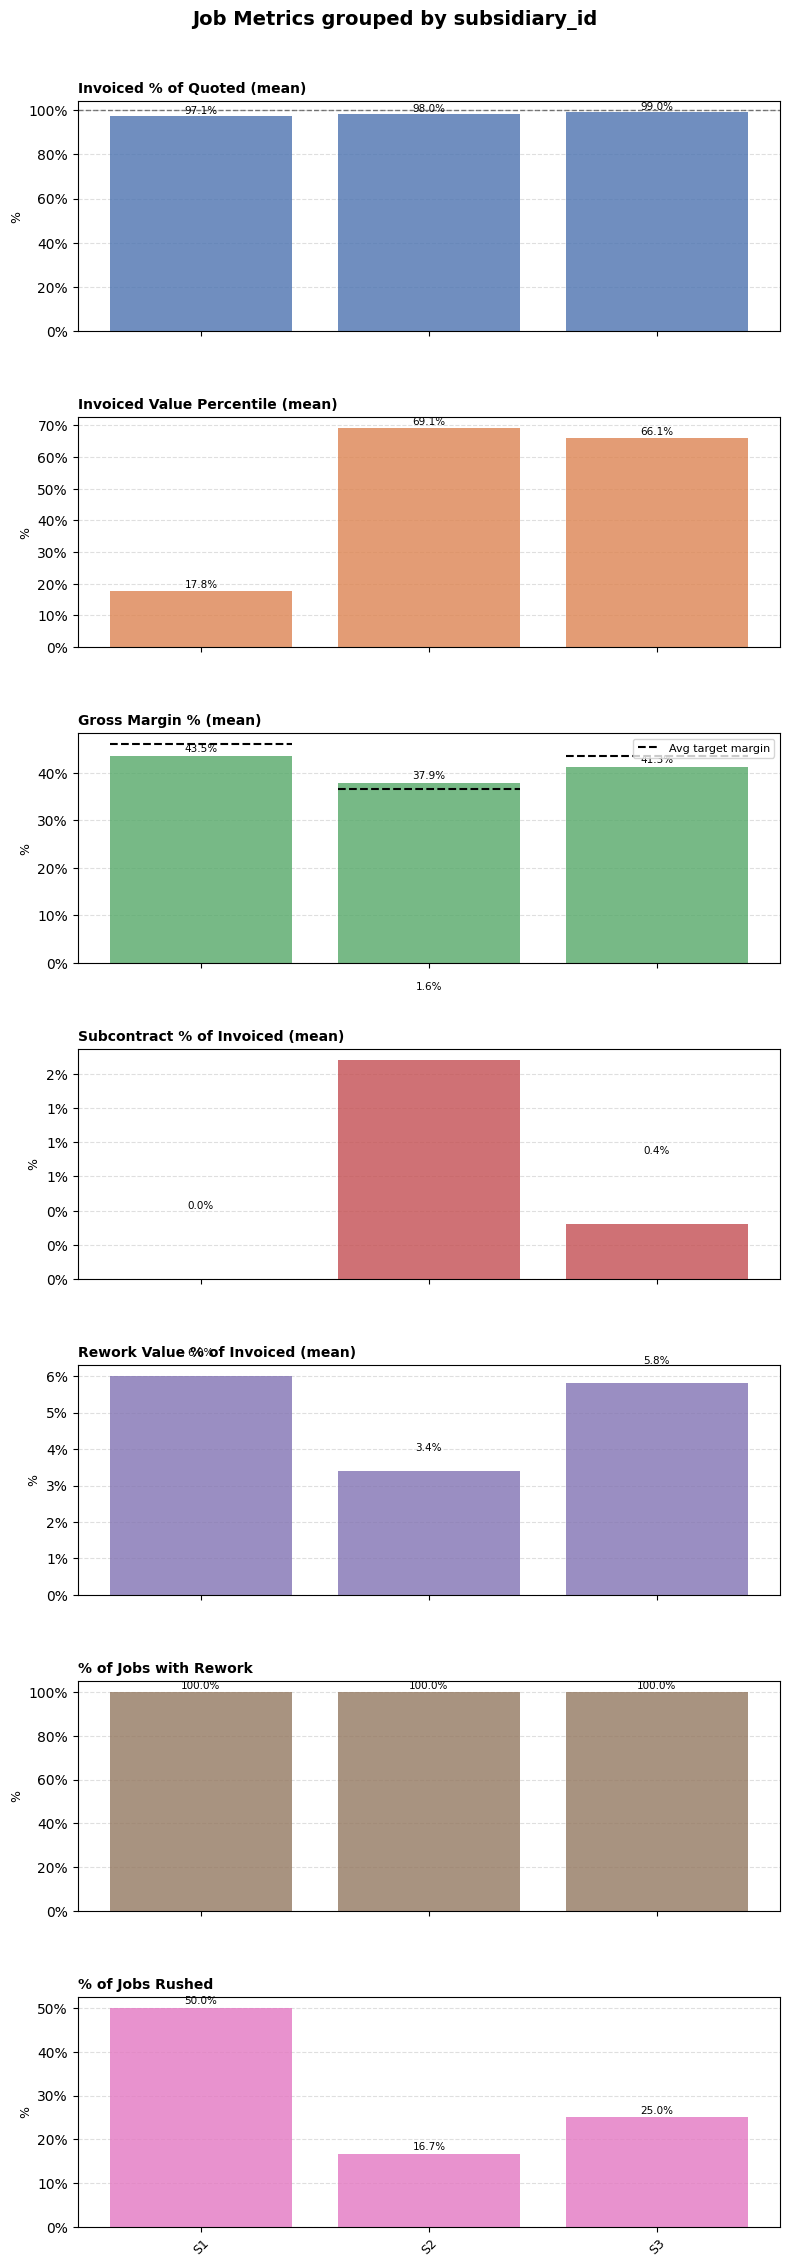


Bot: The rework breakdown by subsidiary has been rendered. As noted previously, AlphaBiolabs (S1) is currently seeing the highest financial impact from rework at 6% of invoiced value, followed closely by ARC Pharma (S3) at 5.8%, with JSS Medical Research (S2) performing best at 3.4%.


'The rework breakdown by subsidiary has been rendered. As noted previously, AlphaBiolabs (S1) is currently seeing the highest financial impact from rework at 6% of invoiced value, followed closely by ARC Pharma (S3) at 5.8%, with JSS Medical Research (S2) performing best at 3.4%.'

In [17]:
await ask_insights('Plot a rework breakdown by subsidiary')

In [18]:
await ask_insights('Which subsidiary has the highest target margin leakage?')


Bot: The subsidiary with the highest target margin leakage is **AlphaBiolabs (S1)**, which is underperforming its target by 2.5 percentage points. 

ARC Pharma (S3) follows closely with a leakage of 2.2 percentage points, while JSS Medical Research (S2) is currently exceeding its target margin (indicated by the negative leakage value).


'The subsidiary with the highest target margin leakage is **AlphaBiolabs (S1)**, which is underperforming its target by 2.5 percentage points. \n\nARC Pharma (S3) follows closely with a leakage of 2.2 percentage points, while JSS Medical Research (S2) is currently exceeding its target margin (indicated by the negative leakage value).'

In [19]:
await ask_insights('Which customer has the most rushed jobs?')


Bot: Customers **C102, C103, C104, and C105** are tied for the highest rate of rushed jobs, with 50% of their projects being classified as "rush" jobs.


'Customers **C102, C103, C104, and C105** are tied for the highest rate of rushed jobs, with 50% of their projects being classified as "rush" jobs.'

In [20]:
await ask_insights('What are the main causes of target leakage?')


Bot: The primary drivers of target margin leakage appear to be operational inefficiency manifesting as rework and, in some cases, high rush rates. The data points to two specific services driving the majority of the leakage:

*   **Workplace Drug Testing (SV1):** This service has the highest rework value impact (10.3% of invoiced value) and a 100% rush rate, contributing to a significant target leakage of 10.4 percentage points.
*   **Phase II/III Clinical Operations (SV4):** This service has the highest overall target margin leakage at 10.5 percentage points. While its rework value impact is lower (3.3%), it is the least profitable service overall, suggesting systemic cost issues beyond just rework.

**QC Batch Release Testing (SV7)** also shows significant leakage (7.3 points) correlated with a 7% rework value impact and a 50% rush rate.

In summary, where you see high rework combined with high rush volumes, you see the most significant margin degradation.


'The primary drivers of target margin leakage appear to be operational inefficiency manifesting as rework and, in some cases, high rush rates. The data points to two specific services driving the majority of the leakage:\n\n*   **Workplace Drug Testing (SV1):** This service has the highest rework value impact (10.3% of invoiced value) and a 100% rush rate, contributing to a significant target leakage of 10.4 percentage points.\n*   **Phase II/III Clinical Operations (SV4):** This service has the highest overall target margin leakage at 10.5 percentage points. While its rework value impact is lower (3.3%), it is the least profitable service overall, suggesting systemic cost issues beyond just rework.\n\n**QC Batch Release Testing (SV7)** also shows significant leakage (7.3 points) correlated with a 7% rework value impact and a 50% rush rate.\n\nIn summary, where you see high rework combined with high rush volumes, you see the most significant margin degradation.'

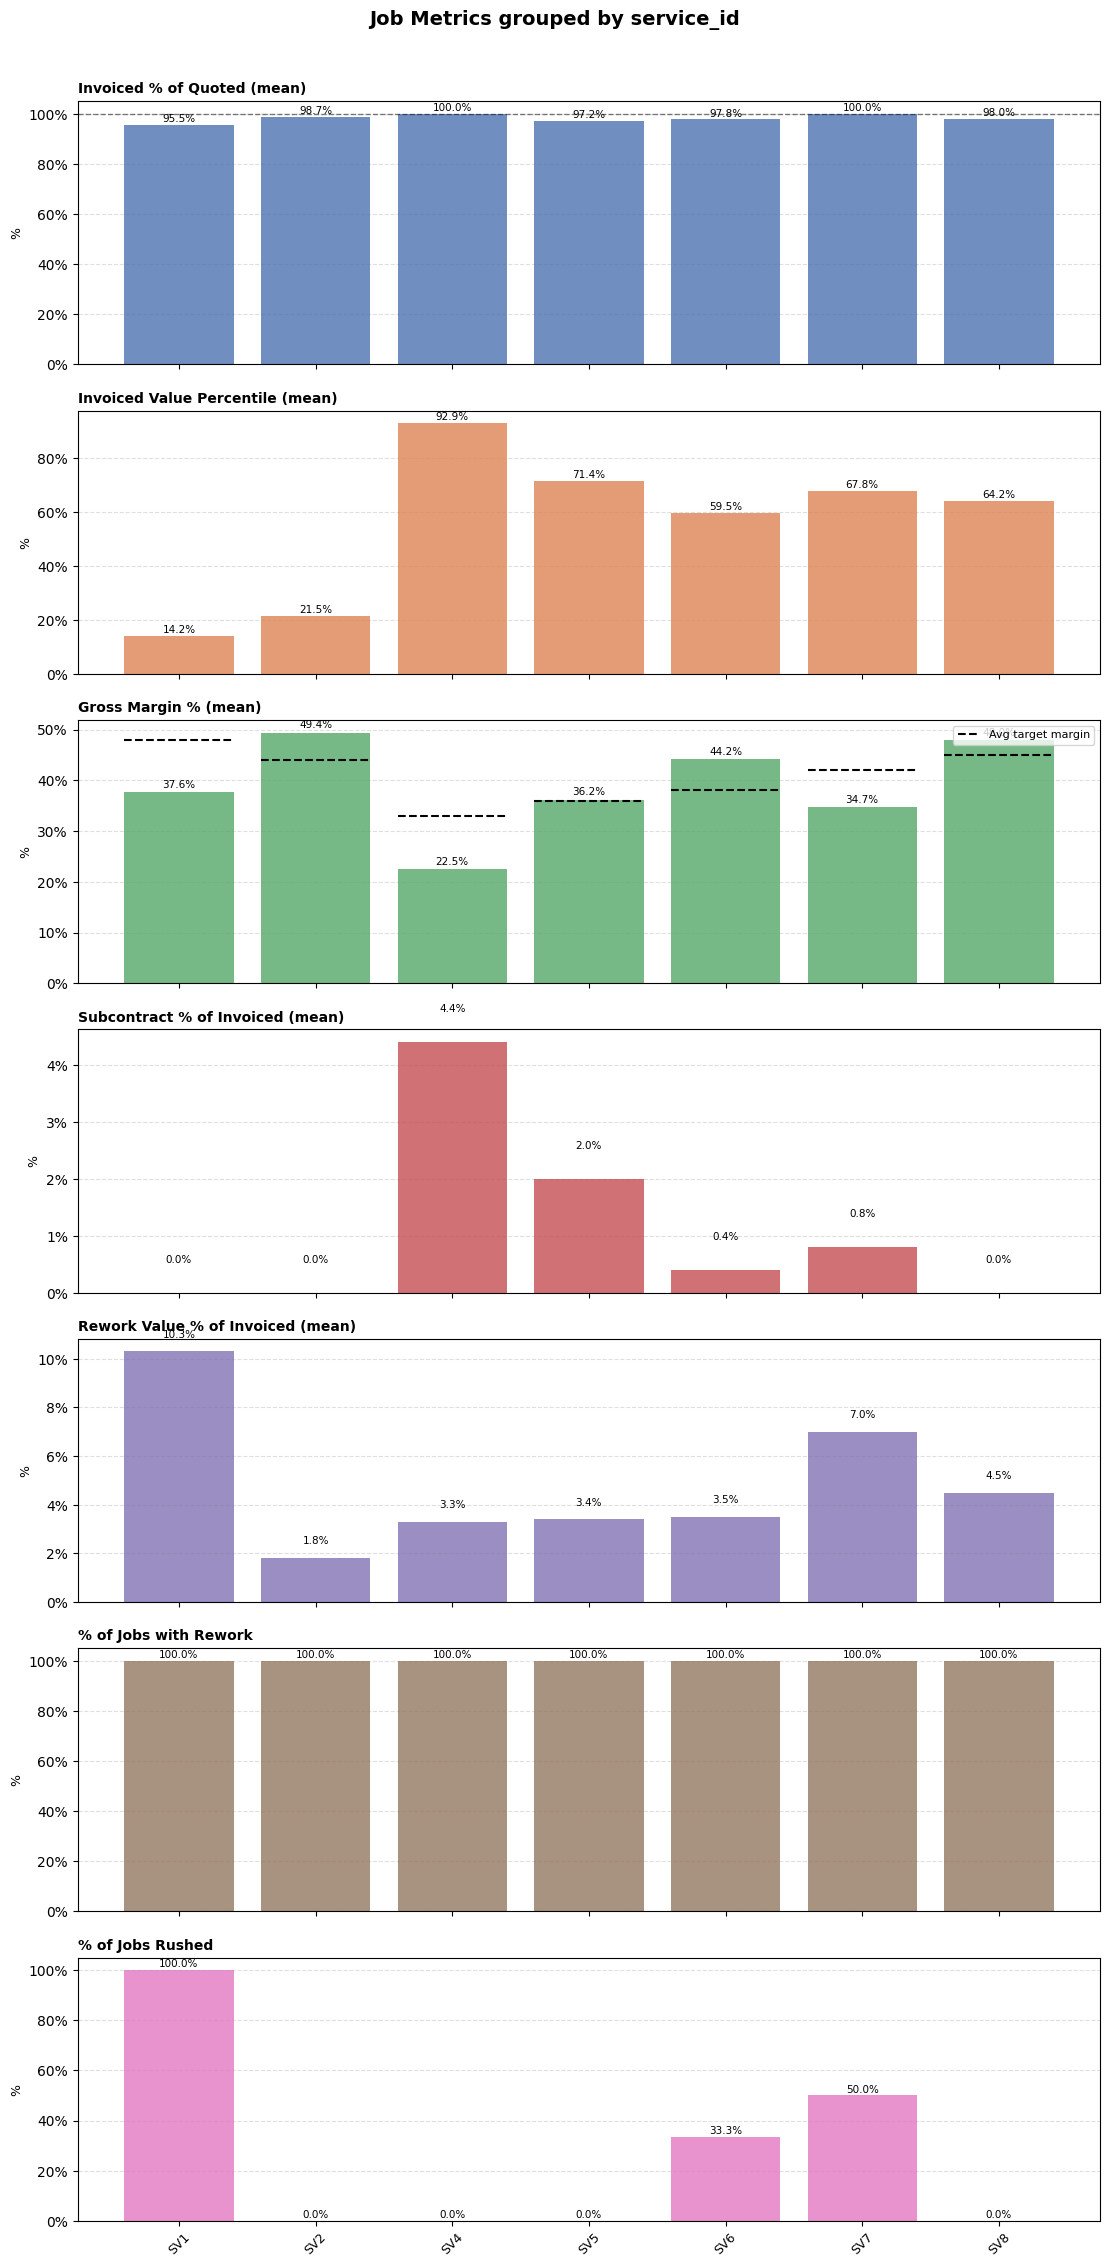


Bot: The job metrics chart grouped by service has been rendered. This visual should help you align the performance across your service portfolio, specifically highlighting the variance between high-performing areas like Medical Writing & Data Management (SV6) and the high-leakage areas like Workplace Drug Testing (SV1) and Phase II/III Clinical Operations (SV4).


'The job metrics chart grouped by service has been rendered. This visual should help you align the performance across your service portfolio, specifically highlighting the variance between high-performing areas like Medical Writing & Data Management (SV6) and the high-leakage areas like Workplace Drug Testing (SV1) and Phase II/III Clinical Operations (SV4).'

In [21]:
await ask_insights('Plot the metrics grouped by service')

### SYNERGIES

scoring.py

In [22]:
from __future__ import annotations

def gross_margin_pct(invoiced, labour, travel, subcontract, rework, other):
    if invoiced <= 0:
        return 0.0
    margin = (
        invoiced - labour - travel - subcontract - rework - other
    ) / invoiced
    return round(margin * 100, 2)

def cross_sell_score(
    adjacency_conf: float,
    sector_fit: float,
    region_fit: float,
    spend_band_fit: float,
    capacity_score: float
) -> float:
    score = (
        0.35 * adjacency_conf
        + 0.20 * sector_fit
        + 0.15 * region_fit
        + 0.15 * spend_band_fit
        + 0.15 * capacity_score
    )
    return round(score, 4)

def priority_band(score: float) -> str:
    if score >= 0.80:
        return "HIGH"
    if score >= 0.65:
        return "MEDIUM"
    return "LOW"

tools.py

In [23]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
# from scoring import gross_margin_pct, cross_sell_score, priority_band

def resolve_customer(customer_name: str) -> dict:
    """
    Resolve a customer name to the closest known group customer.
    """
    match = customers[customers["customer_name"].str.lower() == customer_name.lower()]
    if match.empty:
        return {"status": "not_found", "customer_name": customer_name}
    row = match.iloc[0].to_dict()
    return {"status": "success", "customer": row}

def get_customer_360(customer_id: str) -> dict:
    """
    Return customer profile plus current service history.
    """
    cust = customers[customers["customer_id"] == customer_id]
    hist = history[history["customer_id"] == customer_id]
    if cust.empty:
        return {"status": "not_found", "customer_id": customer_id}
    return {
        "status": "success",
        "customer": cust.iloc[0].to_dict(),
        "service_history": hist.to_dict(orient="records")
    }

def find_cross_sell_opportunities(customer_id: str) -> dict:
    """
    Recommend likely next services across the portfolio.
    """
    cust = customers[customers["customer_id"] == customer_id]
    hist = history[history["customer_id"] == customer_id]
    if cust.empty:
        return {"status": "not_found", "customer_id": customer_id}
    current_services = set(hist["service_id"].tolist())
    sector = cust.iloc[0]["sector"]
    region = cust.iloc[0]["region"]
    spend = float(cust.iloc[0]["current_group_spend_gbp"])
    opportunities = []
    for _, hrow in hist.iterrows():
        anchor = hrow["service_id"]
        rules = adjacency[adjacency["anchor_service_id"] == anchor]
        for _, rule in rules.iterrows():
            recommended = rule["recommended_service_id"]
            if recommended in current_services:
                continue
            svc = services[services["service_id"] == recommended].iloc[0]
            provider = subsidiaries[subsidiaries["subsidiary_id"] == svc["provider_subsidiary_id"]].iloc[0]
            sector_fit = 1.0 if sector in ["Pharma", "Biotech"] and recommended in ["SV5", "SV6", "SV7", "SV8"] else 0.7
            region_fit = 0.9 if region in ["UK", "EU", "Global"] else 0.7
            spend_band_fit = 1.0 if spend >= 200000 else 0.7
            capacity_score = max(0.1, 1 - (float(provider["current_capacity_pct"]) / 100))
            score = cross_sell_score(
                adjacency_conf=float(rule["base_confidence"]),
                sector_fit=sector_fit,
                region_fit=region_fit,
                spend_band_fit=spend_band_fit,
                capacity_score=capacity_score
            )
            opportunities.append({
                "customer_id": customer_id,
                "customer_name": cust.iloc[0]["customer_name"],
                "recommended_service_id": recommended,
                "recommended_service_name": svc["service_name"],
                "recommended_subsidiary_id": svc["provider_subsidiary_id"],
                "recommended_subsidiary_name": provider["subsidiary_name"],
                "estimated_annual_value_gbp": int(svc["avg_deal_size_gbp"]),
                "score": score,
                "priority": priority_band(score),
                "reason": rule["reason"]
            })
    opportunities = sorted(opportunities, key=lambda x: x["score"], reverse=True)
    return {"status": "success", "opportunities": opportunities[:5]}

def find_margin_leaks(customer_id: str | None = None) -> dict:
    """
    Flag jobs where actual margin is below target margin.
    """
    jobs_df = jobs.copy()
    if customer_id:
        jobs_df = jobs_df[jobs_df["customer_id"] == customer_id]
    results = []
    for _, row in jobs_df.iterrows():
        target_margin = float(
            services[services["service_id"] == row["service_id"]].iloc[0]["target_margin_pct"]
        )
        actual_margin = gross_margin_pct(
            invoiced=float(row["invoiced_value_gbp"]),
            labour=float(row["direct_labour_gbp"]),
            travel=float(row["travel_logistics_gbp"]),
            subcontract=float(row["subcontract_gbp"]),
            rework=float(row["rework_gbp"]),
            other=float(row["other_direct_cost_gbp"])
        )
        leak = round(target_margin - actual_margin, 2)
        if leak > 5:
            reasons = []
            if str(row["rush_flag"]) == "Y":
                reasons.append("rush_work_not_fully_recovered")
            if float(row["rework_gbp"]) > 1000:
                reasons.append("rework_cost_high")
            if float(row["travel_logistics_gbp"]) > 1000:
                reasons.append("travel_or_logistics_overrun")
            if float(row["quoted_value_gbp"]) > float(row["invoiced_value_gbp"]):
                reasons.append("quote_to_invoice_erosion")
            results.append({
                "job_id": row["job_id"],
                "customer_id": row["customer_id"],
                "service_id": row["service_id"],
                "actual_margin_pct": actual_margin,
                "target_margin_pct": target_margin,
                "margin_leak_pct": leak,
                "reasons": reasons
            })
    return {"status": "success", "margin_leaks": results}

def prioritise_actions(customer_id: str) -> dict:
    """
    Combine cross-sell and margin findings into a next-best-action list.
    """
    cross_sell = find_cross_sell_opportunities(customer_id)
    leaks = find_margin_leaks(customer_id)
    actions = []
    for leak in leaks.get("margin_leaks", []):
        severity = "HIGH" if leak["margin_leak_pct"] >= 10 else "MEDIUM"
        actions.append({
            "type": "margin_leak",
            "priority": severity,
            "message": f"Review pricing and delivery controls for job {leak['job_id']}; leak={leak['margin_leak_pct']} pts.",
            "approval_required": True
        })
    for opp in cross_sell.get("opportunities", []):
        approval_required = opp["priority"] != "HIGH"
        actions.append({
            "type": "cross_sell",
            "priority": opp["priority"],
            "message": f"Offer {opp['recommended_service_name']} via {opp['recommended_subsidiary_name']} to {opp['customer_name']}.",
            "approval_required": approval_required
        })
    priority_order = {"HIGH": 0, "MEDIUM": 1, "LOW": 2}
    actions = sorted(actions, key=lambda x: priority_order[x["priority"]])
    return {"status": "success", "actions": actions}

### Synergy Agent

In [24]:
from google.adk.agents.llm_agent import Agent
# from tools import (
#     resolve_customer,
#     get_customer_360,
#     find_cross_sell_opportunities,
#     find_margin_leaks,
#     prioritise_actions,
# )

root_agent = Agent(
    model=GeminiWithApiKey(model=model_name, api_key=api_key),
    name="buy_build_revenue_margin_agent",
    description="Finds cross-sell opportunities and margin leaks across a buy-and-build portfolio.",
    instruction="""
You are an enterprise revenue and margin intelligence agent for a buy-and-build group.

Your job:
1. Resolve the customer name with resolve_customer tool.
2. Retrieve the customer 360 with get_customer_360 tool.
3. Identify cross-sell opportunities across subsidiaries with find_cross_sell_opportunities tool.
4. Identify margin leaks for the customer's recent jobs with find_margin_leaks tool.
5. Prioritise recommended actions with prioritise_actions tool.
6. Return a concise executive summary plus a structured JSON block.

Rules:
- Never fabricate customer data.
- Use tools before answering.
- If an action is pricing-sensitive or medium-confidence, mark it as human approval required.
- Keep recommendations concrete and commercial.
    """,
    tools=[
        resolve_customer,
        get_customer_360,
        find_cross_sell_opportunities,
        find_margin_leaks,
        prioritise_actions,
    ],
)


from google.adk import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

APP_NAME = "synergy_app"
USER_ID = "synergy_user_001"
SESSION_ID = "synergy_session_001"

session_service = InMemorySessionService()

# Create a session once for the notebook
session = await session_service.create_session(
    app_name=APP_NAME,
    user_id=USER_ID,
    session_id=SESSION_ID,
)

runner = Runner(
    agent=root_agent,
    app_name=APP_NAME,
    session_service=session_service
)

async def ask_synergy(message: str, session_id: str = SESSION_ID, user_id: str = USER_ID):
    content = types.Content(
        role="user",
        parts=[types.Part(text=message)]
    )

    async for event in runner.run_async(
        user_id=user_id,
        session_id=session_id,
        new_message=content
    ):
        if hasattr(event, "tool_name") and event.tool_name:
            print(f"\nTool Called: {event.tool_name}")

        if hasattr(event, "tool_args") and event.tool_args:
            print(f"   Args: {event.tool_args}")

        if hasattr(event, "raw_event") and event.raw_event:
            raw = event.raw_event
            if isinstance(raw, dict) and "tool" in str(raw).lower():
                print(f"\nRaw Event (possible tool call): {raw}")

        if event.is_final_response():
            text = "\n".join(
                getattr(part, "text", "") for part in event.content.parts if hasattr(part, "text")
            )
            print(f"\nBot: {text}")
            return text

In [25]:
await ask_synergy("Find cross-sell opportunities for MedNova Pharma")


Bot: ### Executive Summary: MedNova Pharma (C101)

MedNova Pharma is a high-value client with a £420k annual spend. Analysis reveals a clear path to increasing share-of-wallet while addressing operational inefficiencies impacting group profitability.

**Key Findings:**
*   **Cross-Sell Opportunity:** There is a high-conviction opportunity to introduce "QC Batch Release Testing" (via ARC Pharma), with an estimated annual value of £140k. Given MedNova's current profile, this is a natural service extension.
*   **Margin Leaks:** Two jobs (J1003 and J1004) are currently underperforming against margin targets due to recurring issues with rework and logistics. Immediate operational review is required to stabilize these accounts.

**Recommendations:**
1.  **Immediate Outreach:** Initiate the cross-sell proposal for QC Batch Release Testing.
2.  **Operational Audit:** Review delivery protocols for jobs J1003 and J1004 to address the 5%–10% margin erosion. These actions require management appr

'### Executive Summary: MedNova Pharma (C101)\n\nMedNova Pharma is a high-value client with a £420k annual spend. Analysis reveals a clear path to increasing share-of-wallet while addressing operational inefficiencies impacting group profitability.\n\n**Key Findings:**\n*   **Cross-Sell Opportunity:** There is a high-conviction opportunity to introduce "QC Batch Release Testing" (via ARC Pharma), with an estimated annual value of £140k. Given MedNova\'s current profile, this is a natural service extension.\n*   **Margin Leaks:** Two jobs (J1003 and J1004) are currently underperforming against margin targets due to recurring issues with rework and logistics. Immediate operational review is required to stabilize these accounts.\n\n**Recommendations:**\n1.  **Immediate Outreach:** Initiate the cross-sell proposal for QC Batch Release Testing.\n2.  **Operational Audit:** Review delivery protocols for jobs J1003 and J1004 to address the 5%–10% margin erosion. These actions require managemen

In [26]:
await ask_synergy("Find cross-sell opportunities for AlphaBiolabs for JSS Medical Research's clients?")


Bot: I was unable to find "AlphaBiolabs" or "JSS Medical Research" in the current portfolio database. 

Please verify the company names or provide the specific customer IDs if they are known by a different entity name within the group.


'I was unable to find "AlphaBiolabs" or "JSS Medical Research" in the current portfolio database. \n\nPlease verify the company names or provide the specific customer IDs if they are known by a different entity name within the group.'

In [27]:
await ask_synergy("Find cross-sell opportunities for AlphaBiolabs subsidiary for JSS Medical Research subsidiary's clients?")


Bot: I have searched the portfolio for both "AlphaBiolabs" and "JSS Medical Research," but neither entity is recognized in the group database.

It is possible these entities are not currently categorized as customers or subsidiary providers under the names provided. To assist you further, please ensure:
1. The companies are correctly registered within the group's current portfolio.
2. If they operate under different legal entities or holding company names, please provide those details.

If you have specific **Customer IDs** for the clients of these entities, I can pull their profiles and identify cross-sell opportunities directly.


'I have searched the portfolio for both "AlphaBiolabs" and "JSS Medical Research," but neither entity is recognized in the group database.\n\nIt is possible these entities are not currently categorized as customers or subsidiary providers under the names provided. To assist you further, please ensure:\n1. The companies are correctly registered within the group\'s current portfolio.\n2. If they operate under different legal entities or holding company names, please provide those details.\n\nIf you have specific **Customer IDs** for the clients of these entities, I can pull their profiles and identify cross-sell opportunities directly.'